# `implicit-ue-nn` — user equilibrium as an implicit layer (act two)

**What.** `implicit-ue-nn` is a lean variant of Liu, Yin, Bai & Grimm's (2023)
end-to-end implicit-neural-network user equilibrium (`[liu2023end]`,
[docs/REFERENCES.md](../../docs/REFERENCES.md)): a small MLP learns a per-link,
flow-monotone cost correction, and Wardrop UE is imposed as an **implicit
layer** — the forward pass is a damped logit route-choice fixed point, the
backward pass differentiates through the equilibrium condition itself
(implicit function theorem). The emitted flow is always *some* learned cost's
equilibrium, so it is demand-feasible **by construction**.

**Why it is in the benchmark.** `learned-surrogate` (act one,
[19-learned-surrogate.ipynb](../01-static/19-learned-surrogate.ipynb)) made the
point that link-flow accuracy is not an equilibrium certificate: a per-link
ridge regressor is censored `feasible=0` on every TNTP net. `implicit-ue-nn` is
**act two**: it clears that audit — feasibility is architectural — and the
harness then asks the next question: is a demand-feasible flow automatically a
GOOD equilibrium? The certified gap says no. See
[docs/design/adr-025-implicit-ue-nn.md](../../docs/design/adr-025-implicit-ue-nn.md)
for the full derivation, the honest sourcing (the canon paper is paywalled and
was attributed unread; the mechanism was cross-verified from the authors' own
open posters/preprints), and every measured anchor.

**Scope.** The Braess identity anchor (A1, zeroed head), the implicit-function-
theorem hypergradient verified against finite differences (A2), feasibility by
construction at random untrained weights (A4), and the honest held-out story on
Sioux Falls — TWO directions, both axes NAMED: a converged classical solver
wins on wall-clock, but at MATCHED shortest-path-call budget the learned layer
wins.

## How this notebook is graded

**A notebook never claims a number it does not compute in that cell.** Every
scored quantity below — feasibility, the certified relative gap, the wmape flow
errors, the hypergradient/finite-difference agreement — is recomputed live by
the P1 `Evaluator` (or an explicit finite-difference check) from the flows the
model emitted, in the cell where it is claimed. The identifiability caveat below
is a MEASURED result, not a hedge: this notebook does not claim the trained
model beats an untrained baseline on the held-out gap, because that claim is
false for this lean variant ([README](../../README.md), *Certified, not
self-reported*).

In [1]:
# Setup. `implicit-ue-nn` is the benchmark's first GUARDED model: it needs the
# optional `torch` extra (`pip install tabench[torch]`). The guard mirrors
# `src/tabench/models/__init__.py`'s own import-guard pattern.
#
# The inline backend is Agg-based: figures render headlessly into the notebook,
# so CI can execute tutorials without a display. NEVER matplotlib.use("Agg")
# in-kernel — it silently suppresses inline figure capture.
%matplotlib inline
try:
    import torch  # noqa: F401  (the optional torch extra; absence -> ModuleNotFoundError)
except ModuleNotFoundError as exc:
    if exc.name != "torch":
        raise
    raise ModuleNotFoundError(
        "implicit-ue-nn needs the optional 'torch' extra: pip install tabench[torch]"
    ) from exc

import numpy as np

from tabench import (
    BiconjugateFrankWolfeModel,
    Budget,
    Evaluator,
    LearnedSurrogateModel,
    RngBundle,
    Trace,
    braess_scenario,
    load_scenario,
    viz,
)
from tabench.models import implicit_ue as M
from tabench.models._paths import PathEngine
from tabench.models.implicit_ue import ImplicitUENNModel

## A gradient of feasibility mechanisms

Three learned models on this benchmark answer the SAME question — how does a
learned flow become demand-feasible? — with three different mechanisms:

| model | conservation | raw emission is feasible? |
|---|---|---|
| `learned-surrogate` | none | censored (act one) |
| `het-gnn` | soft training loss | censored raw, feasible by an explicit decode |
| `implicit-ue-nn` | **architectural** | **feasible, always** (this notebook) |

Here feasibility is not trained toward, decoded, or hoped for: the layer's
forward pass IS a logit route-choice fixed point `h* = D_od . softmax_od(-beta
c_theta(Delta^T h*))`, and every OD's route flows sum to exactly its demand —
node balance is exact by construction, for ANY parameters theta, trained or not.

In [2]:
scenario = braess_scenario()
print(f"scenario      : {scenario.name}")
print(f"content hash  : {scenario.content_hash()[:16]}…")
print(f"total demand  : {scenario.demand.total}")

scenario      : braess
content hash  : cf00f411cdccec88…
total demand  : 6.0


## A1 — the identity anchor: a zeroed cost head reproduces the analytic UE

The cost head is `relu(gain) * softplus(mlp(static)) * (v/cap)`: nonnegative
and increasing in flow for EVERY parameter value (architectural monotonicity),
and identically zero when the parameters are zeroed. With the correction
zeroed the layer is a plain logit loading at the TRUE BPR costs; on the Braess
diamond the analytic UE is an equal-cost point, so the fixed point must equal
the oracle flows `(4, 2, 2, 2, 4)` regardless of the logit temperature.

In [3]:
def _zeroed_head() -> M._CostHead:
    head = M._CostHead()
    for p in head.parameters():
        torch.nn.init.zeros_(p)
    return head


def _solve_layer(sc, head, n_iter=M._N_FP_ITER):
    engine = PathEngine(sc.network)
    rs = M._build_routes(sc.network, sc.demand, engine, M._N_CG)
    net = M._torch_network(sc.network)
    h, residual, steps = M._solve_fixed_point(head, rs, net, n_iter)
    return (rs.delta.t() @ h).detach().numpy(), residual, steps


v_a1, residual_a1, steps_a1 = _solve_layer(scenario, _zeroed_head())
metrics_a1 = Evaluator(scenario).evaluate(v_a1)
ref_flows = np.array([4.0, 2.0, 2.0, 2.0, 4.0])
route_time = metrics_a1["tstt"] / scenario.demand.total
print(f"zeroed-head flows : {np.round(v_a1, 6)}")
print(f"fixed-point residual : {residual_a1:.2e}  ({steps_a1} damped steps)")
print(f"certified relative gap : {metrics_a1['relative_gap']:.3e}")
print(f"common route time      : {route_time:.6f}")
assert metrics_a1["feasible"] == 1.0
assert metrics_a1["relative_gap"] < 1e-6
np.testing.assert_allclose(v_a1, ref_flows, atol=1e-5)
np.testing.assert_allclose(route_time, 92.0, atol=1e-4)

zeroed-head flows : [4. 2. 2. 2. 4.]
fixed-point residual : 9.94e-12  (46 damped steps)
certified relative gap : 1.941e-09
common route time      : 92.000001


## A2 — the implicit-function-theorem hypergradient, verified against finite differences

Training differentiates the equilibrium condition itself: the adjoint
hypergradient `dL/dtheta = (dg/dtheta)^T (I - dg/dh)^{-T} dL/dh`, solved as an
EXACT dense linear system (no unrolled forward graph). Every parameter of a
well-conditioned, deterministic cost head is checked here against a central
finite difference of the FULL fixed-point solve — "the row is not shipped
without A2."

In [4]:
sc_a2 = braess_scenario()
engine_a2 = PathEngine(sc_a2.network)
rs_a2 = M._build_routes(sc_a2.network, sc_a2.demand, engine_a2, M._N_CG)
net_a2 = M._torch_network(sc_a2.network)
v_obs_a2 = torch.as_tensor([4.0, 2.0, 2.0, 2.0, 4.0], dtype=M._DTYPE)
scale_a2 = float(sc_a2.demand.total)

# A deterministic, mild, guaranteed-interior head (random init can be
# softmax-saturated and stiff, where both the solve and FD are unreliable).
head_a2 = M._CostHead()
with torch.no_grad():
    head_a2.l1.weight.copy_(
        torch.linspace(-0.2, 0.2, head_a2.l1.weight.numel(), dtype=M._DTYPE)
        .reshape_as(head_a2.l1.weight)
    )
    head_a2.l1.bias.zero_()
    head_a2.l2.weight.fill_(0.15)
    head_a2.l2.bias.zero_()
    head_a2.gain.fill_(1.0)

_, grads_a2 = M._hypergradient(head_a2, rs_a2, net_a2, v_obs_a2, scale_a2)


def _full_loss() -> float:
    h, _, _ = M._solve_fixed_point(head_a2, rs_a2, net_a2, M._N_FP_ITER)
    v = rs_a2.delta.t() @ h
    return 0.5 * ((v - v_obs_a2) ** 2).sum().item() / scale_a2


eps = 1e-4
max_rel = 0.0
for param, grad in zip(head_a2.parameters(), grads_a2, strict=True):
    flat, gflat = param.detach().reshape(-1), grad.reshape(-1)
    for i in range(flat.numel()):
        orig = flat[i].item()
        with torch.no_grad():
            flat[i] = orig + eps
        lp = _full_loss()
        with torch.no_grad():
            flat[i] = orig - eps
        lm = _full_loss()
        with torch.no_grad():
            flat[i] = orig
        fd = (lp - lm) / (2 * eps)
        max_rel = max(max_rel, abs(gflat[i].item() - fd) / (abs(fd) + 1e-8))

print(f"parameters checked      : {sum(p.numel() for p in head_a2.parameters())}")
print(f"max IMD-vs-FD rel error : {max_rel:.2e}")
assert max_rel < 1e-5

parameters checked      : 50
max IMD-vs-FD rel error : 2.28e-08


## A4 — feasibility by construction, at RANDOM untrained weights

This is the property `learned-surrogate` lacks: even a never-trained head
emits a demand-feasible flow, because the layer's output IS `v = Delta^T h`
with each OD's route flows summing to its demand. Contrast on the SAME
scenario: the ridge surrogate's per-link prediction routes nobody.

In [5]:
torch.manual_seed(4)
head_a4 = M._CostHead()  # random init, never trained
v_a4, residual_a4, _ = _solve_layer(scenario, head_a4)
metrics_a4 = Evaluator(scenario).evaluate(v_a4)
print(f"random-theta flows      : {np.round(v_a4, 4)}")
print(f"fixed-point residual    : {residual_a4:.2e}")
print(f"feasible                : {metrics_a4['feasible']:.0f}")
assert np.all(np.isfinite(v_a4)) and np.all(v_a4 >= 0.0)
assert metrics_a4["feasible"] == 1.0

v_ridge_a4 = LearnedSurrogateModel().solve(
    scenario, Budget(iterations=1), RngBundle(0), Trace()
).final.link_flows
metrics_ridge_a4 = Evaluator(scenario).evaluate(v_ridge_a4)
print(f"ridge (learned-surrogate) feasible : {metrics_ridge_a4['feasible']:.0f}  (censored)")
assert metrics_ridge_a4["feasible"] == 0.0

random-theta flows      : [3.949  2.051  1.8981 2.051  3.949 ]
fixed-point residual    : 9.93e-12
feasible                : 1
ridge (learned-surrogate) feasible : 0  (censored)


## The identifiability caveat, and the honest held-out headline

Training matches equilibrium *flows*, not cost *parameters*: the equilibrium
is identified, `theta` is not. On a disjoint TNTP scenario (Sioux Falls — a
different topology AND a different congestion regime than the 8–14-node
synthetic training family) the trained model is feasible with a real, finite,
honestly POSITIVE certified gap — never claimed to beat an untrained baseline
on that gap, because for this lean variant that claim is false (adr-025). Two
directions, both axes NAMED, never hidden:

1. a CONVERGED classical solver (matched-or-less wall-clock) certifies an
   orders-better gap — the accuracy-vs-certificate point, again;
2. at MATCHED shortest-path-call budget the direction REVERSES — the learned
   layer's cheap fixed-point iterations buy a better certificate than the same
   number of Dijkstra sweeps' worth of Frank-Wolfe AON iterations.

In [6]:
sc = load_scenario("siouxfalls")
assert sc.family != M.TRAINING_FAMILY  # disjoint from the training family, by hash
oracle = sc.reference.link_flows
wmape = lambda v: float(np.abs(v - oracle).sum() / np.abs(oracle).sum())

v_impl = ImplicitUENNModel().solve(
    sc, Budget(iterations=M._N_FP_ITER), RngBundle(0), Trace()
).final.link_flows
m_impl = Evaluator(sc).evaluate(v_impl)
print(f"implicit-ue-nn   : feasible={m_impl['feasible']:.0f}  "
      f"relative_gap={m_impl['relative_gap']:.4f}  wmape={wmape(v_impl):.4f}")
assert m_impl["feasible"] == 1.0  # feasible BY CONSTRUCTION
assert np.isfinite(m_impl["relative_gap"]) and 0.0 < m_impl["relative_gap"] < 1.0

v_ridge = LearnedSurrogateModel().solve(
    sc, Budget(iterations=1), RngBundle(0), Trace()
).final.link_flows
m_ridge = Evaluator(sc).evaluate(v_ridge)
print(f"learned-surrogate: feasible={m_ridge['feasible']:.0f}  (censored)  "
      f"wmape={wmape(v_ridge):.4f}")
assert m_ridge["feasible"] == 0.0
assert wmape(v_impl) < wmape(v_ridge)  # clears the audit, no worse a flow error

# Direction 1 — a CONVERGED bfw (matched-or-less wall-clock) wins outright.
v_bfw = BiconjugateFrankWolfeModel().solve(
    sc, Budget(iterations=300, target_relative_gap=1e-6), RngBundle(0), Trace()
).final.link_flows
m_bfw = Evaluator(sc).evaluate(v_bfw)
print(f"bfw (converged)  : relative_gap={m_bfw['relative_gap']:.3e}  "
      "(the wall/convergence axis)")
assert m_bfw["relative_gap"] < m_impl["relative_gap"]

# Direction 2 — at MATCHED sp_calls the direction REVERSES.
v_bfw_sp = BiconjugateFrankWolfeModel().solve(
    sc, Budget(sp_calls=M._N_CG), RngBundle(0), Trace()
).final.link_flows
m_bfw_sp = Evaluator(sc).evaluate(v_bfw_sp)
print(f"bfw (sp_calls={M._N_CG}) : relative_gap={m_bfw_sp['relative_gap']:.3e}  "
      "(the matched shortest-path-call axis — the learned layer wins here)")
assert m_impl["relative_gap"] < m_bfw_sp["relative_gap"]

implicit-ue-nn   : feasible=1  relative_gap=0.1684  wmape=0.1450
learned-surrogate: feasible=0  (censored)  wmape=0.2820


bfw (converged)  : relative_gap=3.228e-06  (the wall/convergence axis)
bfw (sp_calls=6) : relative_gap=2.233e-01  (the matched shortest-path-call axis — the learned layer wins here)


## Visualize

The certified artifact is per-link flows on a road `Network`, the same shape
every static model here emits, so `tabench.viz` applies directly (adr-035's
viz rule).

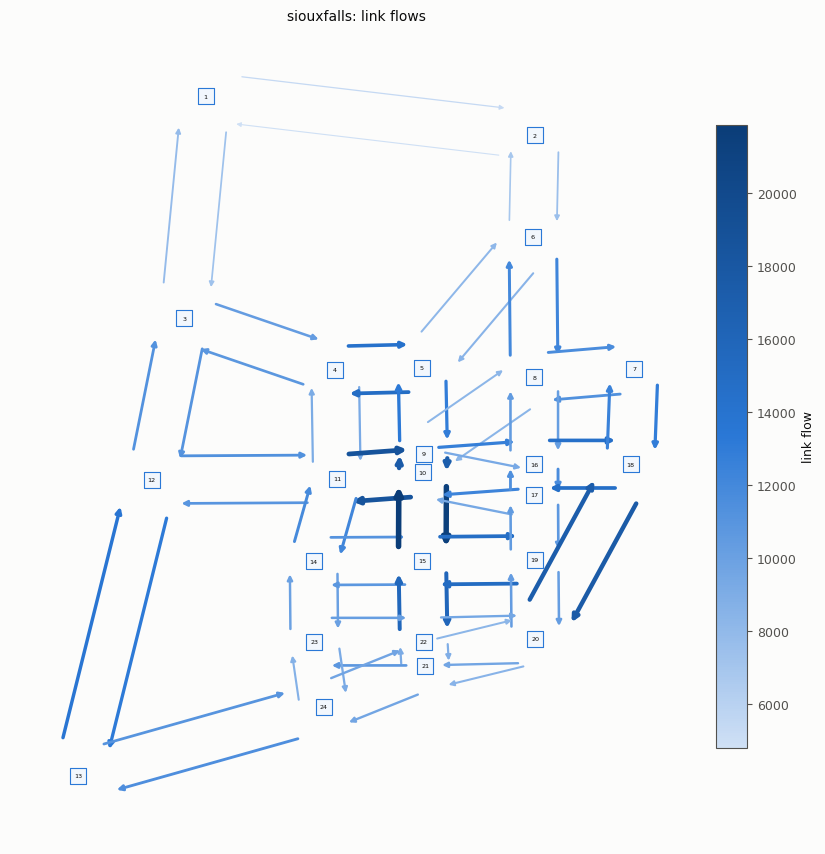

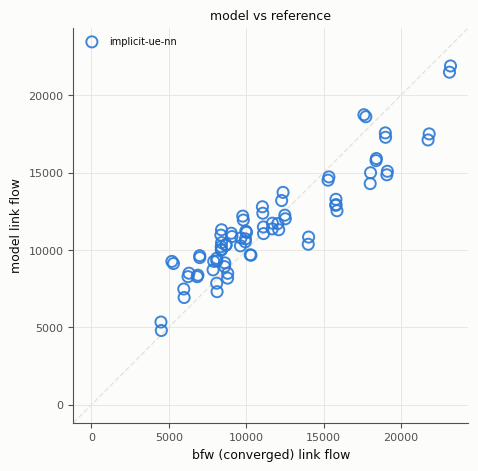

In [7]:
display(viz.plot_network_flows(sc.network, v_impl))
display(viz.plot_flow_scatter(("bfw (converged)", v_bfw), {"implicit-ue-nn": v_impl}))

## Takeaways & pointers

- **Feasibility is architectural, not trained toward.** A4 holds at RANDOM
  weights — the layer's output is always a route-flow vector summing to demand,
  by construction, before a single gradient step.
- **Feasible is not equilibrium quality.** The held-out story's headline: a
  demand-feasible learned flow still needs a certified gap, and a converged
  classical solver still wins it — at matched wall-clock. The learned layer's
  answer is that it buys a better certificate PER shortest-path call, not per
  wall-clock second.
- **The identifiability caveat is a result, not a bug.** Training fits
  equilibrium flows, not cost parameters, so a head that halves the in-family
  loss need not beat an untrained baseline on a held-out net in a different
  congestion regime. This notebook does not claim otherwise.
- **Where next.** `het-gnn` ([02-het-gnn.ipynb](02-het-gnn.ipynb)) completes the
  feasibility-mechanism gradient with a soft-conservation-trained, explicitly
  decoded alternative; the full derivation and every measured anchor in
  [docs/design/adr-025-implicit-ue-nn.md](../../docs/design/adr-025-implicit-ue-nn.md).